# Variable-star classification from AstroM3 spectra

Train GalSpecNet on AstroM3's ten variable-star classes using only the processed LAMOST flux channel. AstroM3 also provides light curves and metadata; omitting them is deliberate, so this stays a clear spectrum-only AstroSpec example.

<img src="../assets/galspecnet.jpeg" alt="model architecture" width="600">

The dataset publisher supplies train/validation/test splits. This notebook uses the full `full_42` split and training-set class weights.

## Install example-only dependencies

The processed release is Parquet-backed and does not need `trust_remote_code`. `scikit-learn` is used only for the familiar per-class report and confusion matrix at the end.

In [1]:
!pip install -q datasets matplotlib scikit-learn tqdm

## Imports

`utils.astrom3` streams the published split and selects the flux row from AstroM3's `(wavelength, flux, flux-error)` representation. Each spectrum is normalized independently by the shared `utils.preprocess` routine, the same one the SDSS examples use.

In [2]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, precision_recall_fscore_support
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd().parent))
import astrospec
from utils import astrom3

torch.manual_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Load AstroM3's supplied full splits

`full_42` is the full split created by the dataset authors with seed 42. The helper reads `ClassLabel` names in exactly the integer order used by the tensors.

In [3]:
class_names = astrom3.class_names()
train_x, train_y = astrom3.load_split('train')
val_x, val_y = astrom3.load_split('validation')
test_x, test_y = astrom3.load_split('test')

print(f'grid: {train_x.shape[1]:,} pixels')
print(f'splits: train={len(train_y):,}, validation={len(val_y):,}, test={len(test_y):,}')
print('classes:', ', '.join(class_names))

grid: 2,575 pixels
splits: train=17,063, validation=2,152, test=2,225
classes: DSCT, EA, EB, EW, HADS, M, ROT, RRAB, RRC, SR


## Inspect spectra and class balance

The release already puts every processed LAMOST spectrum on a 2,575-pixel grid, so the fixed-grid GalSpecNet can consume it directly. Its ten classes are imbalanced. We derive inverse-frequency weights from the **training split only**, so each class contributes equally in expectation to the training loss without leaking validation or test labels.

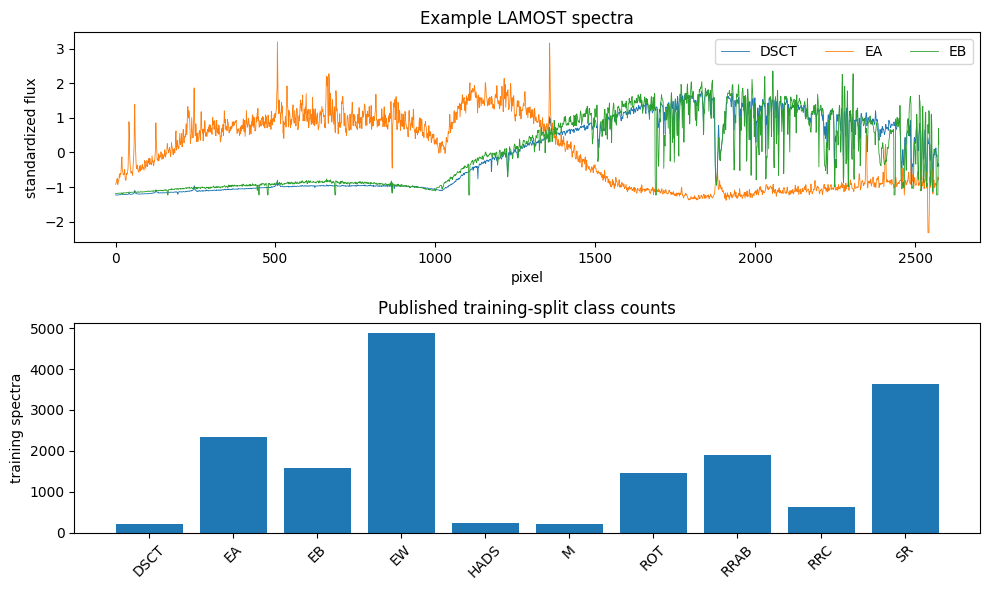

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
for label in range(min(3, len(class_names))):
    i = int(np.flatnonzero(train_y == label)[0])
    axes[0].plot(train_x[i], lw=.6, label=class_names[label])
axes[0].set(xlabel='pixel', ylabel='arcsinh(flux / mean - 1)', title='Example LAMOST spectra')
axes[0].legend(ncol=3)
axes[1].bar(class_names, np.bincount(train_y, minlength=len(class_names)))
axes[1].tick_params(axis='x', rotation=45)
axes[1].set(ylabel='training spectra', title='Published training-split class counts')
fig.tight_layout()

## Batch inputs, weight the loss, and construct a larger classifier

GalSpecNet is a fixed-grid 1-D CNN. `input_length` must agree with the spectrum grid, while `num_classes` produces one final logit per variable-star class. Inverse-frequency weights are normalized to mean one: rare-class mistakes matter more without changing the overall loss scale.

In [5]:
def make_loader(x, y, shuffle=False):
    data = TensorDataset(torch.from_numpy(x), torch.from_numpy(y))
    return DataLoader(data, batch_size=64, shuffle=shuffle)

train_loader = make_loader(train_x, train_y, shuffle=True)
val_loader, test_loader = make_loader(val_x, val_y), make_loader(test_x, test_y)
class_counts = np.bincount(train_y, minlength=len(class_names))
class_weights = class_counts.sum() / (len(class_names) * class_counts)
class_weights = torch.tensor(class_weights / class_weights.mean(), dtype=torch.float32, device=device)
num_epochs = 100
model = astrospec.create_model(
    'galspecnet', input_length=train_x.shape[1], num_classes=len(class_names),
    conv_channels=(1, 64, 128, 256, 128), n_hidden=(1024, 256, 64), dropout=.2,
).to(device)
print(f'{sum(parameter.numel() for parameter in model.parameters()):,} trainable parameters')
dict(zip(class_names, class_weights.cpu().numpy().round(2)))

5,352,138 trainable parameters


{'DSCT': np.float32(2.66),
 'EA': np.float32(0.23),
 'EB': np.float32(0.35),
 'EW': np.float32(0.11),
 'HADS': np.float32(2.42),
 'M': np.float32(2.53),
 'ROT': np.float32(0.38),
 'RRAB': np.float32(0.29),
 'RRC': np.float32(0.88),
 'SR': np.float32(0.15)}

## Train

The training loop uses weighted cross-entropy and cosine learning-rate decay.

In [6]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
history = {'train_loss': [], 'val_accuracy': []}

epoch_bar = tqdm(range(num_epochs), desc='training', unit='epoch')
for epoch in epoch_bar:
    model.train(); total_loss = 0.0
    batches = tqdm(train_loader, desc=f'epoch {epoch + 1}/{num_epochs}', leave=False, unit='batch')
    for x, y in batches:
        optimizer.zero_grad()
        loss = loss_fn(model(x.to(device)), y.to(device))
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(x)
        batches.set_postfix(loss=f'{loss.item():.3f}', lr=f'{optimizer.param_groups[0]["lr"]:.1e}')
    model.eval()
    with torch.no_grad():
        correct = sum((model(x.to(device)).argmax(1).cpu() == y).sum().item() for x, y in val_loader)
    history['train_loss'].append(total_loss / len(train_y))
    history['val_accuracy'].append(correct / len(val_y))
    scheduler.step()
    epoch_bar.set_postfix(loss=f'{history["train_loss"][-1]:.3f}', val_acc=f'{history["val_accuracy"][-1]:.3f}')

training:   0%|          | 0/100 [00:00<?, ?epoch/s]

epoch 1/100:   0%|          | 0/267 [00:00<?, ?batch/s]

epoch 2/100:   0%|          | 0/267 [00:00<?, ?batch/s]

epoch 3/100:   0%|          | 0/267 [00:00<?, ?batch/s]

epoch 4/100:   0%|          | 0/267 [00:00<?, ?batch/s]

...

epoch 96/100:   0%|          | 0/267 [00:00<?, ?batch/s]

epoch 97/100:   0%|          | 0/267 [00:00<?, ?batch/s]

epoch 98/100:   0%|          | 0/267 [00:00<?, ?batch/s]

epoch 99/100:   0%|          | 0/267 [00:00<?, ?batch/s]

epoch 100/100:   0%|          | 0/267 [00:00<?, ?batch/s]

## Evaluate the held-out test split

The result panel reports overall accuracy plus macro and weighted F1. Macro F1 gives every class equal weight, so it is the headline score for this imbalanced ten-class task; weighted F1 reflects the observed class frequencies. The per-class precision, recall, and F1 chart and the row-normalized confusion matrix make it clear where performance is concentrated.

In [7]:
model.eval()
with torch.no_grad():
    prediction = torch.cat([model(x.to(device)).argmax(1).cpu() for x, _ in test_loader]).numpy()

precision, recall, f1, support = precision_recall_fscore_support(test_y, prediction, labels=np.arange(len(class_names)), zero_division=0)
accuracy = accuracy_score(test_y, prediction)
macro_f1 = f1.mean()
weighted_f1 = np.average(f1, weights=support)
print(f'Overall accuracy: {accuracy:.3f} | macro F1: {macro_f1:.3f} | weighted F1: {weighted_f1:.3f}')
print(classification_report(test_y, prediction, target_names=class_names, zero_division=0))

Overall accuracy: 0.514 | macro F1: 0.345 | weighted F1: 0.509
              precision    recall  f1-score   support

        DSCT       0.09      0.08      0.09        24
          EA       0.23      0.23      0.23       301
          EB       0.18      0.16      0.17       198
          EW       0.57      0.61      0.59       681
        HADS       0.06      0.04      0.05        26
           M       0.31      0.36      0.33        22
         ROT       0.58      0.54      0.56       196
        RRAB       0.39      0.42      0.41       234
         RRC       0.19      0.14      0.16        79
          SR       0.85      0.86      0.86       464

    accuracy                           0.51      2225
   macro avg       0.35      0.35      0.34      2225
weighted avg       0.50      0.51      0.51      2225



Visualize the results

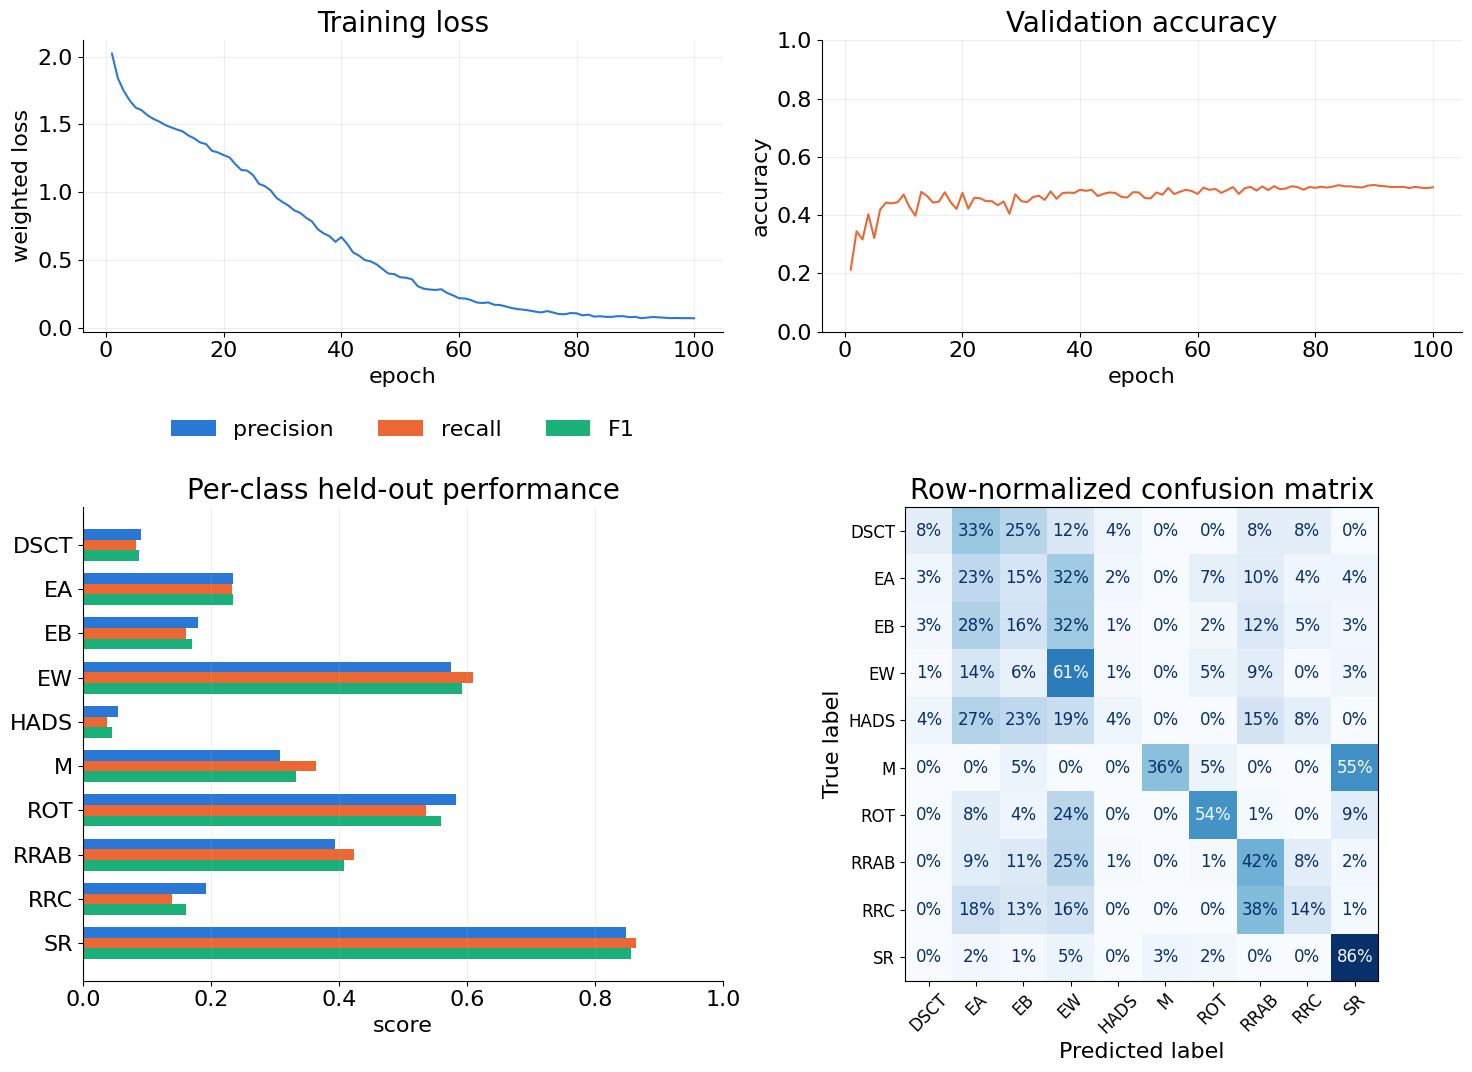

In [9]:
blue, orange, aqua = '#2a78d6', '#eb6834', '#1baf7a'
plt.rcParams.update({
    'font.size': 16, 'axes.titlesize': 20, 'axes.labelsize': 16,
    'xtick.labelsize': 16, 'ytick.labelsize': 16, 'legend.fontsize': 16,
})

fig, axes = plt.subplots(2, 2, figsize=(15, 11), gridspec_kw={'height_ratios': [.8, 1.3]})

epochs = np.arange(1, len(history['train_loss']) + 1)
axes[0, 0].plot(epochs, history['train_loss'], color=blue)
axes[0, 0].set(xlabel='epoch', ylabel='weighted loss', title='Training loss')
axes[0, 1].plot(epochs, history['val_accuracy'], color=orange)
axes[0, 1].set(xlabel='epoch', ylabel='accuracy', ylim=(0, 1), title='Validation accuracy')
for axis in axes[0]:
    axis.spines[['top', 'right']].set_visible(False)
    axis.grid(alpha=.2)

positions = np.arange(len(class_names)); height = .24
axes[1, 0].barh(positions - height, precision, height, label='precision', color=blue)
axes[1, 0].barh(positions, recall, height, label='recall', color=orange)
axes[1, 0].barh(positions + height, f1, height, label='F1', color=aqua)
axes[1, 0].set(yticks=positions, yticklabels=class_names, xlim=(0, 1), xlabel='score', title='Per-class held-out performance')
axes[1, 0].invert_yaxis(); axes[1, 0].spines[['top', 'right']].set_visible(False)
axes[1, 0].grid(axis='x', alpha=.2)
axes[1, 0].legend(ncol=3, loc='lower center', bbox_to_anchor=(.5, 1.1), frameon=False)

ConfusionMatrixDisplay.from_predictions(test_y, prediction, display_labels=class_names, normalize='true', values_format='.0%', xticks_rotation=45, ax=axes[1, 1], colorbar=False, cmap='Blues', text_kw={'fontsize': 12})
axes[1, 1].set_title('Row-normalized confusion matrix')
axes[1, 1].tick_params(labelsize=12)
fig.tight_layout()

## Next steps

This notebook uses the flux channel only. AstroM3 also provides wavelength, flux uncertainty, light curves, and catalogue features.